<a href="https://colab.research.google.com/github/UsmanArif169/Machine-Learning-Algorithms-/blob/main/ROC_AUC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import make_classification

In [3]:
# dataset

X, y = make_classification(n_samples = 1000)    # make balance class

In [4]:
print(X[:5])
print(y[:5])

[[ 1.53526595 -1.06301607  1.94288599 -0.62752654  0.092256   -1.48693142
  -0.08415756 -1.42872464  1.94877028  0.632322    0.16930354  0.7022379
  -0.25104597 -0.89971577  1.52187537 -0.38425426 -2.04577116 -0.89749085
  -0.80324482  0.25258009]
 [ 0.39923067 -0.33286515  1.1994977  -0.05394505 -0.74971001  0.90894648
  -3.63288566  1.3639665   0.17135534 -0.09142107 -1.59436398  0.11947207
   1.74087176  0.52633317 -1.67483629  1.04611416 -0.77877655  0.10190607
   0.39200543 -1.25788255]
 [-0.4543215   0.19362644 -2.48020978  0.5107739   1.42381832 -0.98524601
   1.01005109  1.75796974  0.40313575  1.9535315  -0.45166484  0.85975458
  -1.38517017  2.05297094 -1.24138747 -1.4590535   0.90472237  0.95364536
  -0.88714381 -1.18154227]
 [-0.0457177   1.13644346 -1.10728615  0.9227945  -0.12720873  0.28534659
   0.28587199  0.62318459 -0.09633831 -0.56346421  1.09155731  2.29136697
   1.28952575  0.94278674 -0.29657612 -0.95637275 -1.99792704 -0.34272985
   0.69145804 -0.29715753]
 [-1.

In [5]:
from sklearn.linear_model import LogisticRegression

In [6]:
model = LogisticRegression()
model.fit(X,y)

LogisticRegression()

In [7]:
from sklearn.metrics import roc_curve, auc

In [8]:
# Probabilities

y_prob = model.predict_proba(X)[:,1]

# ROC

fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

In [10]:
print('FPR :', fpr)
print('TPR :' ,tpr)
print('threshlods :', thresholds)

FPR : [0.         0.         0.         0.00200803 0.00200803 0.00401606
 0.00401606 0.0060241  0.0060241  0.00803213 0.00803213 0.01004016
 0.01004016 0.01606426 0.01606426 0.01807229 0.01807229 0.02008032
 0.02008032 0.02208835 0.02208835 0.02610442 0.02610442 0.02811245
 0.02811245 0.03012048 0.03012048 0.03212851 0.03212851 0.03614458
 0.03614458 0.04216867 0.04216867 0.04618474 0.04618474 0.04819277
 0.04819277 0.0562249  0.0562249  0.062249   0.062249   0.06425703
 0.06425703 0.07028112 0.07028112 0.07228916 0.07228916 0.07630522
 0.07630522 0.07831325 0.07831325 0.08232932 0.08232932 0.08433735
 0.08433735 0.08634538 0.08634538 0.10441767 0.10441767 0.11044177
 0.11044177 0.1124498  0.1124498  0.11445783 0.11445783 0.12048193
 0.12048193 0.13453815 0.13453815 0.13654618 0.13654618 0.14257028
 0.14257028 0.14457831 0.14457831 0.14859438 0.14859438 0.18273092
 0.18273092 0.18875502 0.18875502 0.21285141 0.21285141 0.21485944
 0.21485944 0.22891566 0.22891566 0.23092369 0.23092369 

In [11]:
import matplotlib.pyplot as plt


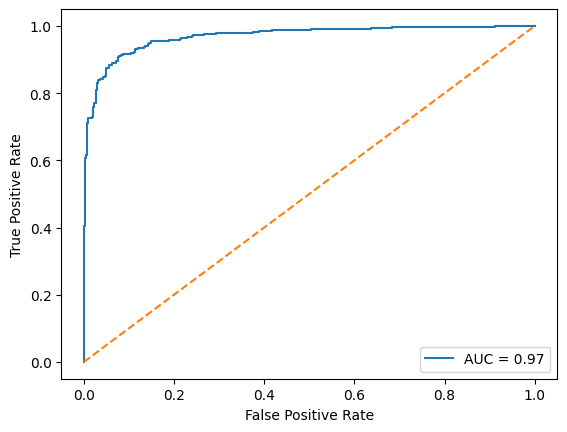

In [12]:
plt.plot (fpr, tpr, label = f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

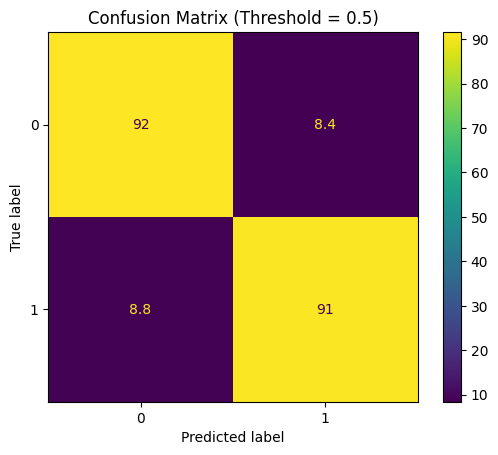

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Convert probability to class prediction
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y, y_pred)

# Convert to percentage (row-wise normalization)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent)

disp.plot()
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()